***Install CleanVision for Clean DataSet***

In [ ]:
pip install cleanvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 41.3 MB/s eta 0:00:00


***Install Pillow***

In [ ]:
pip install matplotlib pillow

***Set the Data Set Path and CSV File loding***

In [ ]:
import pandas as pd
fold_info = pd.read_csv("/content/drive/MyDrive/FinalThesis/ImageProcessing/BreaKHis/Folds.csv")
fold_info["label"] = fold_info["filename"].str.extract("(malignant|benign)")
fold_info.head()

,fold,mag,grp,filename,label
0,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,benign
1,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,benign
2,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,benign
3,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,benign
4,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,benign


***Select Fold to and marge path to image ***

In [ ]:
selected_fold=2
selected_fold_data = fold_info.query("fold == @selected_fold")\
                              .copy().reset_index(drop=True)
selected_fold_data["filename"] = ("/content/drive/MyDrive/FinalThesis/ImageProcessing/BreaKHis/"
                                  + selected_fold_data["filename"])

In [ ]:
selected_fold_data.head(5)

,fold,mag,grp,filename,label
0,2,100,train,/content/drive/MyDrive/FinalThesis/ImageProces...,benign
1,2,100,train,/content/drive/MyDrive/FinalThesis/ImageProces...,benign
2,2,100,train,/content/drive/MyDrive/FinalThesis/ImageProces...,benign
3,2,100,train,/content/drive/MyDrive/FinalThesis/ImageProces...,benign
4,2,100,train,/content/drive/MyDrive/FinalThesis/ImageProces...,benign


***Select Train and Test Data Set***

In [ ]:
# Step 1: Use data in selected fold (2) with magnification factor >= 40
train = selected_fold_data.query("mag >= 40 and grp == 'train'")
test = selected_fold_data.query("mag >= 40 and grp == 'test'")


***Visualization of Total Data Set***

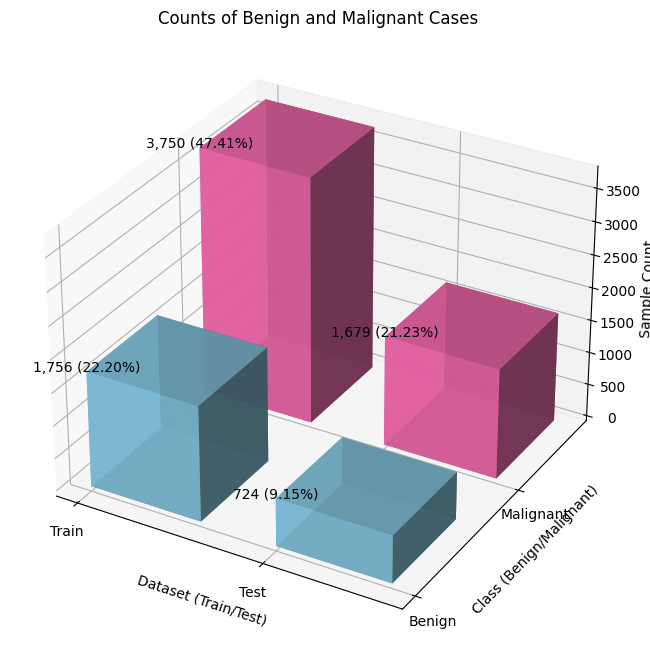

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Get counts for both train and test sets
train_benign =train["label"].value_counts().get('benign')  # Count of benign (0)
train_malignant = train["label"].value_counts().get('malignant')  # Count of malignant (1)
test_benign = test["label"].value_counts().get('benign')  # Count of benign (0)
test_malignant =test["label"].value_counts().get('malignant')  # Count of malignant (1)


# Prepare data for 3D bar chart

datasets = ['Train', 'Test']
Classes = ['Benign', 'Malignant']

# Create a 3D plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')



# X-axis positions (0 for Train, 1 for Test)
xpos = np.array([0, 0, 1, 1])  # First two for Train, next two for Test

# Y-axis positions (0 for Benign, 1 for Malignant)
ypos = np.array([0, 1, 0, 1 ])  # Benign and Malignant for each dataset

# Z-axis values (counts)
zpos = np.zeros(4)  # Start bars from z = 0

# Bar heights (number of samples)
dz = [train_benign, train_malignant, test_benign, test_malignant]

# Create the bars
ax.bar3d(xpos, ypos, zpos, dx=0.6, dy=0.6, dz=dz, color=['skyblue', 'hotpink','skyblue', 'hotpink',],alpha=0.8)


# Set labels
ax.set_xlabel('Dataset (Train/Test)')
ax.set_ylabel('Class (Benign/Malignant)')
ax.set_zlabel('Sample Count')

ax.set_title('Counts of Benign and Malignant Cases')

# Set tick labels
ax.set_xticks([0, 1])
ax.set_xticklabels(datasets)
ax.set_yticks([0, 1])
ax.set_yticklabels(Classes)


# Add bar labels
for i in range(len(dz)):
    ax.text(xpos[i], ypos[i], dz[i], f"{dz[i]:,} ({dz[i]/sum(dz):.2%})",
            color='black', ha='center')

plt.show()


***Visualization Train Data Set***

<ipython-input-8-6aedada86272>:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(dataset)


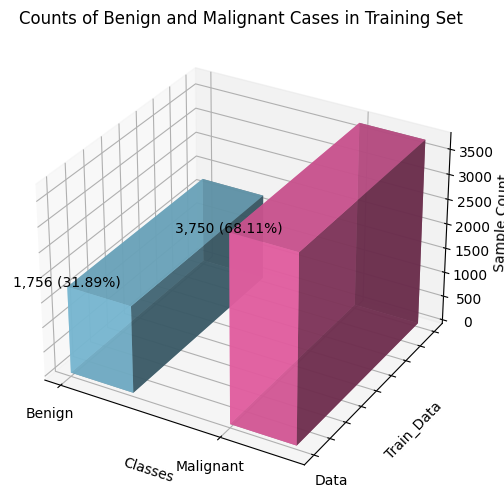

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Get counts for the training set
train_benign = train["label"].value_counts().get('benign')  # Count of benign (0)
train_malignant = train["label"].value_counts().get('malignant')  # Count of malignant (1)

# Prepare data for 3D bar chart
Classes = ['Benign', 'Malignant']
dataset=['Train','Data']


# Create a 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# X-axis positions for Benign and Malignant
xpos = np.array([0, 1])  # Benign at 0, Malignant at 1

# Y-axis positions (only one dataset here, so set to 0)
ypos = np.zeros(len(Classes))  # Only one dataset

# Z-axis values (start bars from z = 0)
zpos = np.zeros(len(Classes))

# Bar heights (number of samples)
dz = [train_benign, train_malignant]

# Create the bars
ax.bar3d(xpos, ypos, zpos, dx=0.4, dy=0.4, dz=dz, color=['skyblue', 'hotpink'], alpha=0.8)

# Set labels
ax.set_xlabel('Classes')
ax.set_ylabel('Train_Data')
ax.set_zlabel('Sample Count')

ax.set_title('Counts of Benign and Malignant Cases in Training Set')

# Set tick labels
ax.set_xticks(xpos)
ax.set_xticklabels(Classes)
ax.set_yticklabels(dataset)


# Add bar labels
for i in range(len(dz)):
    ax.text(xpos[i], ypos[i], dz[i], f"{dz[i]:,} ({dz[i]/sum(dz):.2%})", color='black', ha='center')

plt.show()


***Leveling Classes of Train Data Set***

In [ ]:
import pandas as pd

# Step 1: Use data in selected fold (2) with magnification factor >= 40
train = selected_fold_data.query("mag >= 40 and grp == 'train'")
test = selected_fold_data.query("mag >= 40 and grp == 'test'")

# Step 2: Check the initial shape of the train and test sets
initial_train_shape, initial_test_shape = train.shape, test.shape
print(f"Initial train shape: {initial_train_shape}, Initial test shape: {initial_test_shape}")

# Step 3: Filter benign cases from the test set
benign_from_test = test[test['label'] == 'benign']

# Step 4: Concatenate the benign cases from test to train
train = pd.concat([train, benign_from_test], ignore_index=True)

# Step 5: Remove benign cases from the test set to keep only malignant
test = test[test['label'] != 'benign']  # This will keep only malignant cases

# Step 6: Check the new shape of the train and test sets
new_train_shape, new_test_shape = train.shape, test.shape
print(f"New train shape: {new_train_shape}, New test shape: {new_test_shape}")

# Optionally, print the unique labels again to confirm
print("Unique labels in train:", train['label'].unique())
print("Unique labels in test:", test['label'].unique())


Initial train shape: (5506, 5), Initial test shape: (2403, 5)
New train shape: (6230, 5), New test shape: (1679, 5)
Unique labels in train: ['benign' 'malignant']
Unique labels in test: ['malignant']


***Visualization Train Data Set after Leveling***

<ipython-input-10-6aedada86272>:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(dataset)


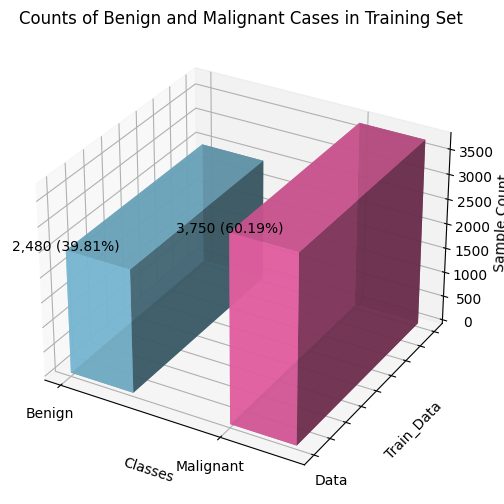

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Get counts for the training set
train_benign = train["label"].value_counts().get('benign')  # Count of benign (0)
train_malignant = train["label"].value_counts().get('malignant')  # Count of malignant (1)

# Prepare data for 3D bar chart
Classes = ['Benign', 'Malignant']
dataset=['Train','Data']


# Create a 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# X-axis positions for Benign and Malignant
xpos = np.array([0, 1])  # Benign at 0, Malignant at 1

# Y-axis positions (only one dataset here, so set to 0)
ypos = np.zeros(len(Classes))  # Only one dataset

# Z-axis values (start bars from z = 0)
zpos = np.zeros(len(Classes))

# Bar heights (number of samples)
dz = [train_benign, train_malignant]

# Create the bars
ax.bar3d(xpos, ypos, zpos, dx=0.4, dy=0.4, dz=dz, color=['skyblue', 'hotpink'], alpha=0.8)

# Set labels
ax.set_xlabel('Classes')
ax.set_ylabel('Train_Data')
ax.set_zlabel('Sample Count')

ax.set_title('Counts of Benign and Malignant Cases in Training Set')

# Set tick labels
ax.set_xticks(xpos)
ax.set_xticklabels(Classes)
ax.set_yticklabels(dataset)


# Add bar labels
for i in range(len(dz)):
    ax.text(xpos[i], ypos[i], dz[i], f"{dz[i]:,} ({dz[i]/sum(dz):.2%})", color='black', ha='center')

plt.show()


***Visualizaiton of Classes in Train Data Set***

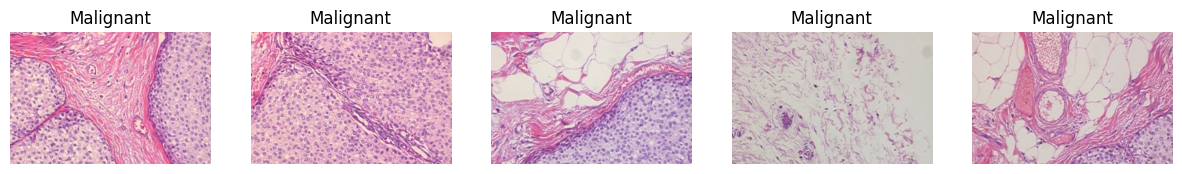

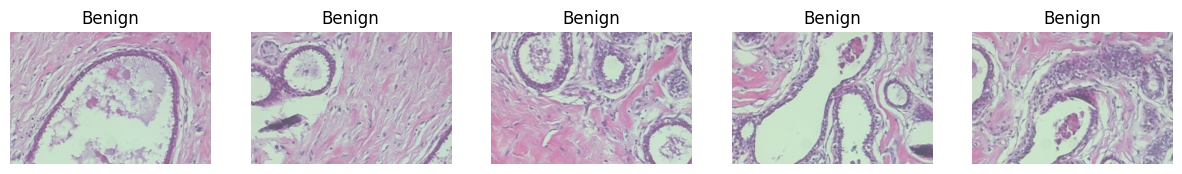

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Assuming you have loaded fold_info and processed selected_fold_data as mentioned in your code

# Extract labels from filenames and add to the DataFrame
train["label"] = train["filename"].str.extract("(malignant|benign)")

# Display 5 images from the malignant class
malignant_images = train[train["label"] == "malignant"].head(5)

plt.figure(figsize=(15, 5))
for i, filename in enumerate(malignant_images["filename"]):
    plt.subplot(2, 5, i+1)
    img = mpimg.imread(filename)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Malignant')
plt.show()

# Display 5 images from the benign class
benign_images = train[train["label"] == "benign"].head(5)

plt.figure(figsize=(15, 5))
for i, filename in enumerate(benign_images["filename"]):
    plt.subplot(2, 5, i+1)
    img = mpimg.imread(filename)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Benign')
plt.show()


**Displaying different magnifying factors of images**

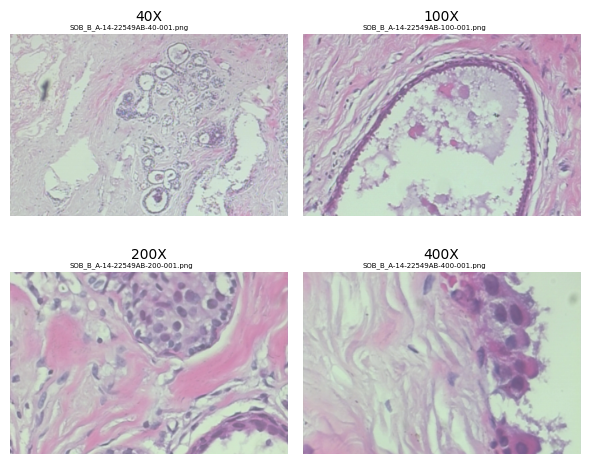

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(6, 5.5), dpi=100, tight_layout=True)
sample_images = train.groupby("mag", as_index=False).first()
for ax, row in zip(axes.flat, sample_images.itertuples()):
    img = Image.open(row.filename)
    ax.imshow(img)
    ax.set_title(f"{row.mag}X", size=10, pad=10, weight=100)
    ax.text(150, -15, row.filename.split("/")[-1], size=5)
    ax.axis("off")

***Check data issues***


Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


  0%|          | 0/6230 [00:00<?, ?it/s]

  0%|          | 0/6230 [00:00<?, ?it/s]

Issue checks completed. 330 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | exact_duplicates |          250 |
|  1 | odd_size         |           74 |
|  2 | near_duplicates  |            6 |
|  3 | dark             |            0 |
|  4 | light            |            0 |
|  5 | odd_aspect_ratio |            0 |
|  6 | low_information  |            0 |
|  7 | blurry           |            0 |
|  8 | grayscale        |            0 | 

----------------- exact_duplicates images ------------------

Number of examples with this issue: 250
Examples representing most severe instances of this issue:

Set: 0


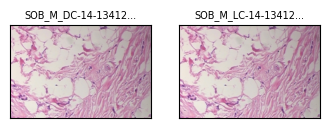

Set: 1


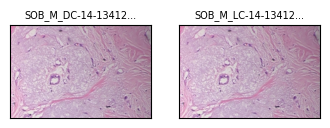

Set: 2


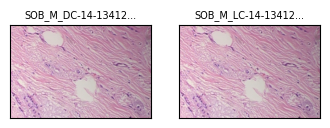

Set: 3


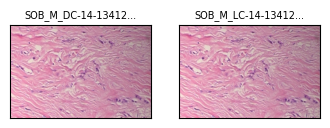

--------------------- odd_size images ----------------------

Number of examples with this issue: 74
Examples representing most severe instances of this issue:



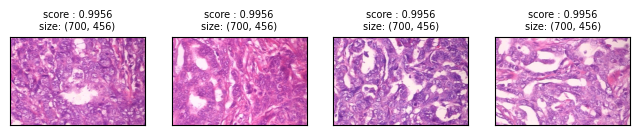

------------------ near_duplicates images ------------------

Number of examples with this issue: 6
Examples representing most severe instances of this issue:

Set: 0


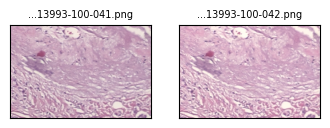

Set: 1


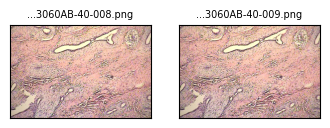

Set: 2


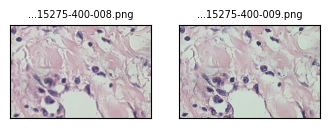

In [ ]:
from PIL import Image
from cleanvision import Imagelab
imagelab = Imagelab(filepaths=list(train["filename"]))
imagelab.find_issues()
imagelab.report(verbosity=4)


***Visualaization Data Issues Report***

<ipython-input-20-e8a31e45cba6>:55: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


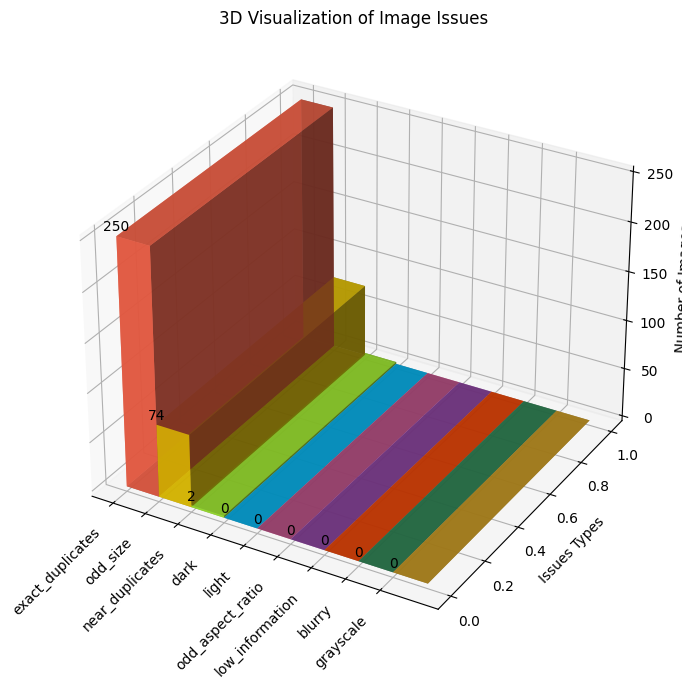

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Data from the report
data = {
    'issue_type': [
        'exact_duplicates', 'odd_size', 'near_duplicates', 'dark', 'light',
        'odd_aspect_ratio', 'low_information', 'blurry', 'grayscale'
    ],
    'num_images': [250, 74, 2, 0, 0, 0, 0, 0, 0]
}

# X positions (we can treat each issue type as a separate bar on the x-axis)
x_pos = np.arange(len(data['issue_type']))

# Y position is always 0 (since we're plotting in 3D, y-axis will just separate the bars visually)
y_pos = np.zeros(len(data['issue_type']))

# Z positions (base of the bars will be 0)
z_pos = np.zeros(len(data['num_images']))

# Heights of the bars (this will be the number of images)
bar_heights = np.array(data['num_images'])

# Bar dimensions (dx and dy define the size of each bar on the x and y axis)
dx = np.ones(len(data['issue_type']))  # width of bars in x-direction
dy = np.ones(len(data['issue_type']))  # width of bars in y-direction

# Define colors for the bars (you can customize these)
colors = ['#FF6347', '#FFD700', '#ADFF2F', '#00BFFF', '#FF69B4', '#BA55D3', '#FF4500', '#2E8B57', '#DAA520']

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D bars
ax.bar3d(x_pos, y_pos, z_pos, dx, dy, bar_heights, color=colors, alpha=0.8)

# Set labels and title

ax.set_ylabel('Issues Types')
ax.set_zlabel('Number of Images')
ax.set_title('3D Visualization of Image Issues')

# Set x-ticks to match issue types
ax.set_xticks(x_pos)
ax.set_xticklabels(data['issue_type'], rotation=45, ha='right')

# Display the values on top of each bar
for i in range(len(bar_heights)):
    ax.text(x_pos[i], y_pos[i], bar_heights[i] + 5, f"{bar_heights[i]:,}", ha='center')

# Show the plot
plt.tight_layout()
plt.show()


***Clean Data Issues***

In [ ]:
# Find issues with duplicate and odd-sized images
problemes = imagelab.issues[["is_exact_duplicates_issue", "is_near_duplicates_issue", "is_odd_size_issue"]]

In [ ]:
#Create a Boolean column indicating whether an image has one of the specified issues
a_des_problemes = problemes.any(axis=1).reset_index().rename(columns={"index": "nom_fichier", 0: "a_des_problemes"})

In [ ]:
# Check that file names match
assert a_des_problemes["nom_fichier"].equals(train["filename"])

In [ ]:
# Delete all images having any of the specified problems
train = train[~a_des_problemes["a_des_problemes"]]

In [ ]:
# Validate again after deleting images with problems
imagelab = Imagelab(filepaths=list(train["filename"]))
imagelab.find_issues()
imagelab.report(verbosity=4)

Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


  0%|          | 0/5900 [00:00<?, ?it/s]

  0%|          | 0/5900 [00:00<?, ?it/s]

Issue checks completed. 0 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | dark             |            0 |
|  1 | light            |            0 |
|  2 | odd_aspect_ratio |            0 |
|  3 | low_information  |            0 |
|  4 | blurry           |            0 |
|  5 | grayscale        |            0 |
|  6 | odd_size         |            0 |
|  7 | exact_duplicates |            0 |
|  8 | near_duplicates  |            0 | 



***Visualization Report After Clean Issues***

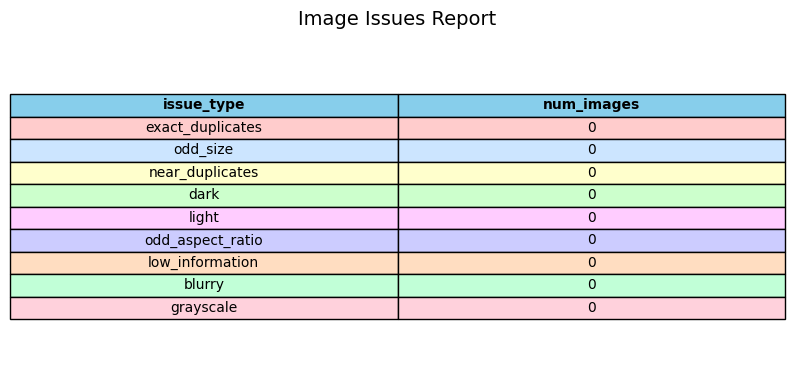

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from the report
data = {
    'issue_type': [
        'exact_duplicates', 'odd_size', 'near_duplicates', 'dark', 'light',
        'odd_aspect_ratio', 'low_information', 'blurry', 'grayscale'
    ],
    'num_images': [0, 0, 0, 0, 0, 0, 0, 0, 0]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Function to create a colorful table
def create_colorful_table(df):
    fig, ax = plt.subplots(figsize=(8, 4))  # Set figure size

    # Hide axes
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_frame_on(False)

    # Color map for the rows (alternating colors)
    colors = ['#FFCCCC', '#CCE5FF', '#FFFFCC', '#CCFFCC', '#FFCCFF', '#CCCCFF', '#FFDDC1', '#C1FFD7', '#FFD1DC']

    # Create the table
    table = ax.table(cellText=df.values,
                     colLabels=df.columns,
                     cellLoc='center',
                     loc='center')

    # Style each row with alternating colors
    for i in range(len(df)):
        for j in range(len(df.columns)):
            table[(i+1, j)].set_facecolor(colors[i % len(colors)])

    # Set the header color
    for j in range(len(df.columns)):
        table[(0, j)].set_facecolor('#87CEEB')
        table[(0, j)].set_text_props(weight='bold', color='black')

    # Adjust the layout
    table.scale(1.2, 1.2)  # Scale the table for better fit
    plt.title('Image Issues Report', fontsize=14)
    plt.tight_layout()
    plt.show()

# Call the function to display the colorful table
create_colorful_table(df)


***Visulaization Train Data Set After Clean***

<ipython-input-27-6aedada86272>:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(dataset)


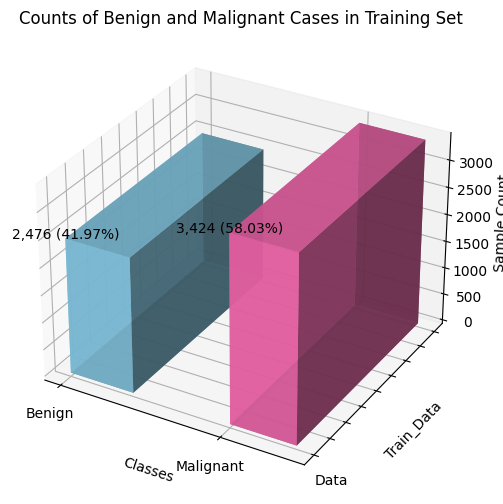

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Get counts for the training set
train_benign = train["label"].value_counts().get('benign')  # Count of benign (0)
train_malignant = train["label"].value_counts().get('malignant')  # Count of malignant (1)

# Prepare data for 3D bar chart
Classes = ['Benign', 'Malignant']
dataset=['Train','Data']


# Create a 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# X-axis positions for Benign and Malignant
xpos = np.array([0, 1])  # Benign at 0, Malignant at 1

# Y-axis positions (only one dataset here, so set to 0)
ypos = np.zeros(len(Classes))  # Only one dataset

# Z-axis values (start bars from z = 0)
zpos = np.zeros(len(Classes))

# Bar heights (number of samples)
dz = [train_benign, train_malignant]

# Create the bars
ax.bar3d(xpos, ypos, zpos, dx=0.4, dy=0.4, dz=dz, color=['skyblue', 'hotpink'], alpha=0.8)

# Set labels
ax.set_xlabel('Classes')
ax.set_ylabel('Train_Data')
ax.set_zlabel('Sample Count')

ax.set_title('Counts of Benign and Malignant Cases in Training Set')

# Set tick labels
ax.set_xticks(xpos)
ax.set_xticklabels(Classes)
ax.set_yticklabels(dataset)


# Add bar labels
for i in range(len(dz)):
    ax.text(xpos[i], ypos[i], dz[i], f"{dz[i]:,} ({dz[i]/sum(dz):.2%})", color='black', ha='center')

plt.show()


***Data Augmentation***

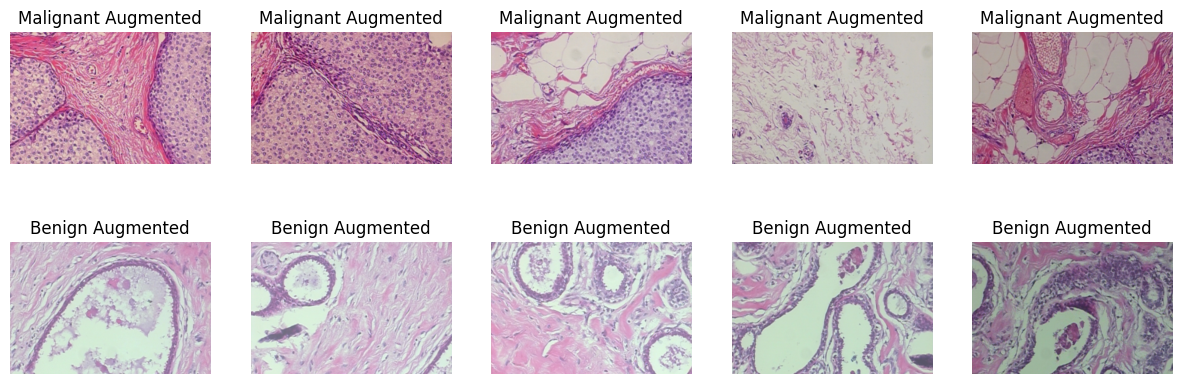

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
import tensorflow as tf

# Assuming you have loaded fold_info and processed selected_fold_data as mentioned in your code

# Extract labels from filenames and add to the DataFrame
train["label"] = train["filename"].str.extract("(malignant|benign)")

# Define augmentation functions
def augment_image(image):
    # Example augmentation (you can add more augmentations as needed)
    # Here, we'll just flip the image horizontally
    img = tf.image.random_flip_left_right(image)  # Horizontal mirror flip
    img = tf.image.random_flip_up_down(image)  # 1 for horizontal flip
    img = tf.image.random_brightness(image,0.2)

    return img

# Display augmented images
plt.figure(figsize=(15, 5))

# Display augmented images for the malignant class
for i, filename in enumerate(malignant_images["filename"]):
    img = mpimg.imread(filename)
    augmented_img = augment_image(img)
    plt.subplot(2, 5, i+1)
    plt.imshow(augmented_img)
    plt.axis('off')
    plt.title('Malignant Augmented')

# Display augmented images for the benign class
for i, filename in enumerate(benign_images["filename"]):
    img = mpimg.imread(filename)
    augmented_img = augment_image(img)
    plt.subplot(2, 5, 6+i)  # Start index from 6 for second row
    plt.imshow(augmented_img)
    plt.axis('off')
    plt.title('Benign Augmented')

plt.show()


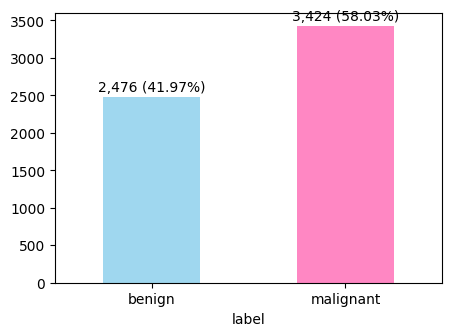

In [ ]:

classes = dict(benign=0, malignant=1)
class_names = list(classes.keys())
label_counts = train["label"].value_counts(ascending=True)
ax = label_counts.plot.bar(color=["skyblue", "hotpink"], alpha=0.8,
                           figsize=(5, 3.5))
ax.bar_label(ax.containers[0], padding=2,
             labels=[f"{x:,} ({x/len(train):.2%})" for x in label_counts])
ax.set_xticklabels(["benign", "malignant"], rotation=0);

***Create Data Set For Base Model***

In [ ]:
from typing import Tuple
import tensorflow as tf
#size=299
IMG_SIZE =128
#before batch=26/28/32/64
BATCH_SIZE = 32

def load_image(filename: str, label: int) -> Tuple[tf.Tensor, str]:
    file = tf.io.read_file(filename)
    img = tf.image.decode_png(file, channels=3)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)

    # Data augmentation
    # Apply augmentation only to benign images
    if label == 0:  # Assuming label 0 corresponds to benign
        img = tf.image.random_flip_left_right(img)  # Horizontal mirror flip
        img = tf.image.random_flip_up_down(img)  # Vertical mirror flip
        img = tf.image.random_brightness(img,0.4)
    # Normalization
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

In [ ]:
from sklearn.model_selection import train_test_split
# Assuming train and test are DataFrames containing filenames and labels
SEED = 51432

train_ratio = 0.7  # 70% of data for training
valid_ratio = 0.2  # 15% of data for validation
test_ratio = 0.1  # 15% of data for testing

# Split the data into train and remaining data
X_train, X_remaining, y_train, y_remaining = train_test_split(
    train["filename"], train["label"].map(classes),
    train_size=train_ratio, stratify=train["label"].map(classes), random_state=SEED
)

# Split the remaining data into validation and test sets
X_valid, X_test, y_valid, y_test = train_test_split(
    X_remaining, y_remaining,
    test_size=test_ratio / (valid_ratio + test_ratio),
    stratify=y_remaining, random_state=SEED
)

# Prepare training dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .map(load_image).batch(BATCH_SIZE)

# Prepare validation dataset
validation_ds = tf.data.Dataset.from_tensor_slices((X_valid, y_valid)) \
    .map(load_image).batch(BATCH_SIZE)

# Prepare test dataset
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(load_image).batch(BATCH_SIZE)

***Split Train Data Set into Train, Validation and Test Data Set***

<ipython-input-32-f5c85a9fd80c>:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


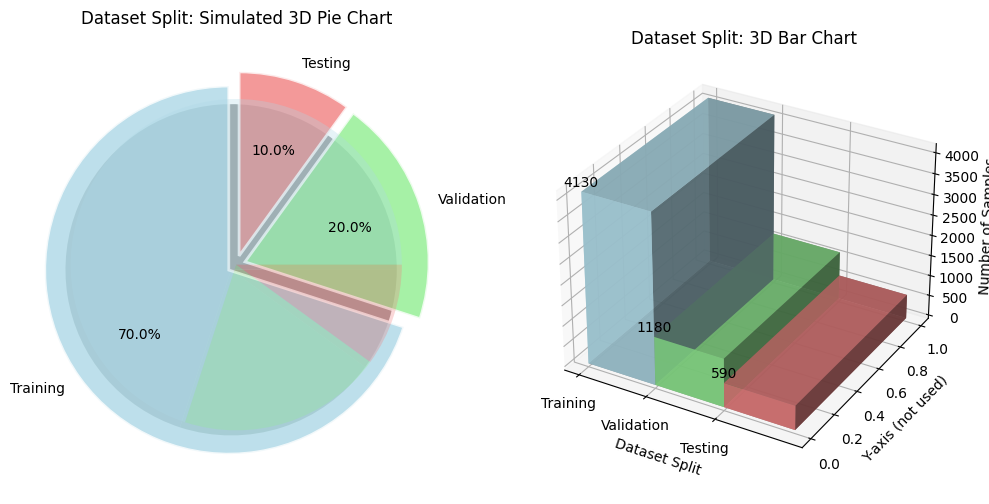

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Data for the charts
sizes = [X_train.shape[0], X_valid.shape[0], X_test.shape[0]]  # [X_train, X_valid, X_test]
labels = ['Training', 'Validation', 'Testing']
colors = ['lightblue', 'lightgreen', 'lightcoral']

# Create a figure with two subplots: 3D pie chart (simulated) and 3D bar chart
fig = plt.figure(figsize=(12, 6))

# Simulated 3D Pie Chart (2D pie with depth-like effect)
ax1 = fig.add_subplot(121)

# Create the 2D pie chart with "exploded" wedge property for 3D simulation effect
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
                                   wedgeprops={'linewidth': 2, 'edgecolor': 'white', 'alpha': 0.8},
                                   explode=(0.05, 0.05, 0.05))

# Add a shadow effect to make it feel more 3D
ax1.pie(sizes, labels=None, colors=colors, shadow=True, radius=0.9, wedgeprops={'linewidth': 0, 'alpha': 0.3})

# Set the title and properties to resemble 3D look
ax1.axis('equal')  # Equal aspect ratio ensures that the pie is drawn as a circle.
ax1.set_title('Dataset Split: Simulated 3D Pie Chart')

# 3D Bar Chart
ax2 = fig.add_subplot(122, projection='3d')

# X-axis positions for the bars
x_pos = np.arange(len(labels))

# Y position is 0 (since we're creating a 3D chart)
y_pos = np.zeros(len(labels))

# Z position is the base of the bars (0 for all bars)
z_pos = np.zeros(len(sizes))

# Bar heights (number of samples in each set)
dz = sizes

# Bar dimensions
dx = np.ones(len(labels))  # Width of bars on x-axis
dy = np.ones(len(labels))  # Width of bars on y-axis (it just gives depth to the 3D bar)

# Create the 3D bars
ax2.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color=colors, alpha=0.8)

# Set labels
ax2.set_xlabel('Dataset Split')
ax2.set_ylabel('Y-axis (not used)')
ax2.set_zlabel('Number of Samples')
ax2.set_title('Dataset Split: 3D Bar Chart')

# Set x-tick labels (Training, Validation, Testing)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels)

# Annotate the bars
for i in range(len(sizes)):
    ax2.text(x_pos[i], y_pos[i], dz[i] + 50, f'{dz[i]}', ha='center', va='bottom')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plots
plt.show()


***Create Compile and Fit Model Function***

In [ ]:

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics

MAX_EPOCHS = 30
BASE_LEARNING_RATE = 0.0001
#BASE_LEARNING_RATE =  0.001

def compile_and_fit_model(
    model: tf.keras.Model,
    learning_rate: float=BASE_LEARNING_RATE,
    epochs: int=MAX_EPOCHS
) -> tf.keras.callbacks.History:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.AUC(name="roc_auc"), "binary_accuracy"]
    )
    early_stopping = EarlyStopping(min_delta=1e-4, patience=5, verbose=1,
                                   restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(factor=0.5, patience=4, verbose=1)
    history = model.fit(train_ds, validation_data=validation_ds,
                        epochs=epochs, callbacks=[early_stopping, reduce_lr])
    # Plot training metrics
    performance_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(ncols=2, figsize=(11, 4))
    for ax, metric in zip(axes.flat, ["Accuracy", "Loss"]):
        performance_df.filter(like=metric.lower()).plot(ax=ax)
        ax.set_title(metric, size=14, pad=10)
        ax.set_xlabel("epoch")

***Create Evaluate Model Function***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn import metrics
import tensorflow as tf  # Assuming you're using TensorFlow models

def evaluate_model(model: tf.keras.Model, dataset: tf.data.Dataset = test_ds) -> None:
    # Evaluate model on the test dataset
    loss, auc, accuracy = model.evaluate(dataset, verbose=0)

    # Create a DataFrame for metrics
    metrics_df = pd.DataFrame({
        'Metric': ['ROC-AUC', 'Accuracy', 'Loss'],
        'Value': [auc, accuracy, loss]
    })

    # Style the metrics DataFrame
    styled_metrics = metrics_df.style.background_gradient(cmap="coolwarm") \
                                         .set_caption(f"Evaluation Metrics for {model.name}") \
                                         .format({'Value': "{:.3f}"})  # Format for the 'Value' column only

    # Display the styled metrics table
    display(styled_metrics)

    # Get labels and predictions for each batch in dataset
    results = [(labels, model.predict(images, verbose=0).reshape(-1))
               for images, labels in dataset.take(-1)]
    labels = np.concatenate([x[0] for x in results])
    preds = np.concatenate([x[1] for x in results])

    # Convert classification report to a DataFrame
    class_report = classification_report(labels, preds.round().astype("uint8"), output_dict=True)
    class_report_df = pd.DataFrame(class_report).T

    # Style the classification report with a color gradient, formatting numeric columns
    styled_report = class_report_df.style.background_gradient(cmap="coolwarm") \
                                         .set_caption(f"Classification Report for {model.name}")

    # Format only numeric columns in the classification report
    for col in class_report_df.columns[1:]:  # Skip the first column (class names)
        styled_report = styled_report.format({col: "{:.3f}"})  # Format numeric columns

    # Display the styled classification report
    display(styled_report)

    # Plot additional metrics (ROC Curve, Precision-Recall Curve, Confusion Matrix)
    fig, axes = plt.subplots(ncols=3, figsize=(20, 4), dpi=160)
    curves = [metrics.RocCurveDisplay, metrics.PrecisionRecallDisplay]
    for ax, curve in zip(axes[:2], curves):
        curve.from_predictions(labels, preds, ax=ax, name=model.name)
    metrics.ConfusionMatrixDisplay.from_predictions(
        labels, preds.round().astype("uint8"), ax=axes[2], colorbar=False,
    )
    titles = ["ROC-AUC Curve", "Precision-Recall Curve", "Confusion Matrix"]
    for ax, title in zip(axes.flat, titles):
        ax.set_title(title, size=14, pad=10)

    plt.tight_layout()
    plt.show()

# Example call to the function:
# evaluate_model(your_model, your_test_dataset)


***Create Base Models:***

***EfficientNetB0***

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# Replace the existing model with MobileNetV1
EfficientNetB0= EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))



# Add your own dense layers on top of MobileNetV1
model1 = tf.keras.Sequential([
    EfficientNetB0,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Assuming binary classification
])



***Train EfficientNetB0 Model***

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 611s 4s/step - binary_accuracy: 0.7534 - loss: 0.4888 - roc_auc: 0.8320 - val_binary_accuracy: 0.6737 - val_loss: 0.6821 - val_roc_auc: 0.6685 - learning_rate: 1.0000e-04
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 498s 4s/step - binary_accuracy: 0.9217 - loss: 0.1903 - roc_auc: 0.9775 - val_binary_accuracy: 0.5432 - val_loss: 0.6885 - val_roc_auc: 0.5219 - learning_rate: 1.0000e-04
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 541s 4s/step - binary_accuracy: 0.9602 - loss: 0.1174 - roc_auc: 0.9918 - val_binary_accuracy: 0.5822 - val_loss: 0.6826 - val_roc_auc: 0.5537 - learning_rate: 1.0000e-04
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 496s 4s/step - binary_accuracy: 0.9754 - loss: 0.0807 - roc_auc: 0.9952 - val_binary_accuracy: 0.6415 - val_loss: 0.6249 - val_roc_auc: 0.7086 - learning_rate: 1.0000e-04
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 521s 4s/step - binary_accuracy: 0.9854 - loss: 0.0535 - roc_auc: 0.9984 - val_binary_accuracy: 0.6754 - val_loss: 0.

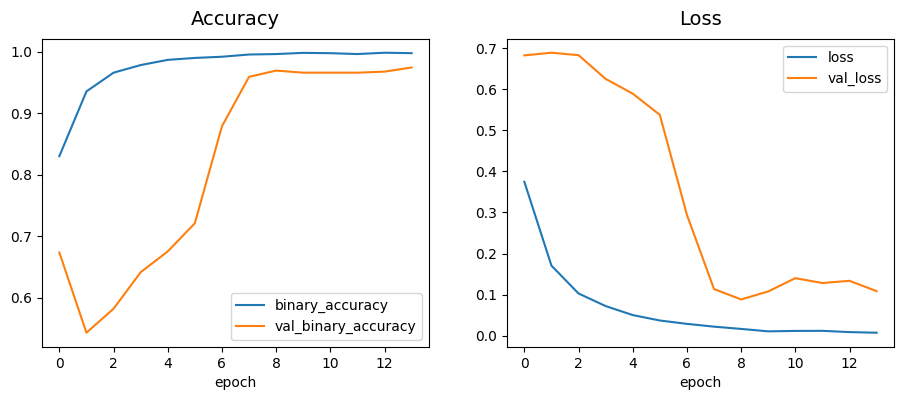

In [ ]:
# Compile and fit the model
Efficientnet_history= compile_and_fit_model(model1)

In [ ]:
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 4, 4, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,049,248 (49.78 MB)

 Trainable params: 4,335,741 (16.54 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 8,671,484 (33.08 MB)

***Evaluate EfficientNet Model***

,Metric,Value
0,ROC-AUC,0.997
1,Accuracy,0.966
2,Loss,0.076


,precision,recall,f1-score,support
0,0.960000,0.967742,0.963855,248.000
1,0.976471,0.970760,0.973607,342.000
accuracy,0.969492,0.969492,0.969492,0.969
macro avg,0.968235,0.969251,0.968731,590.000
weighted avg,0.969547,0.969492,0.969508,590.000


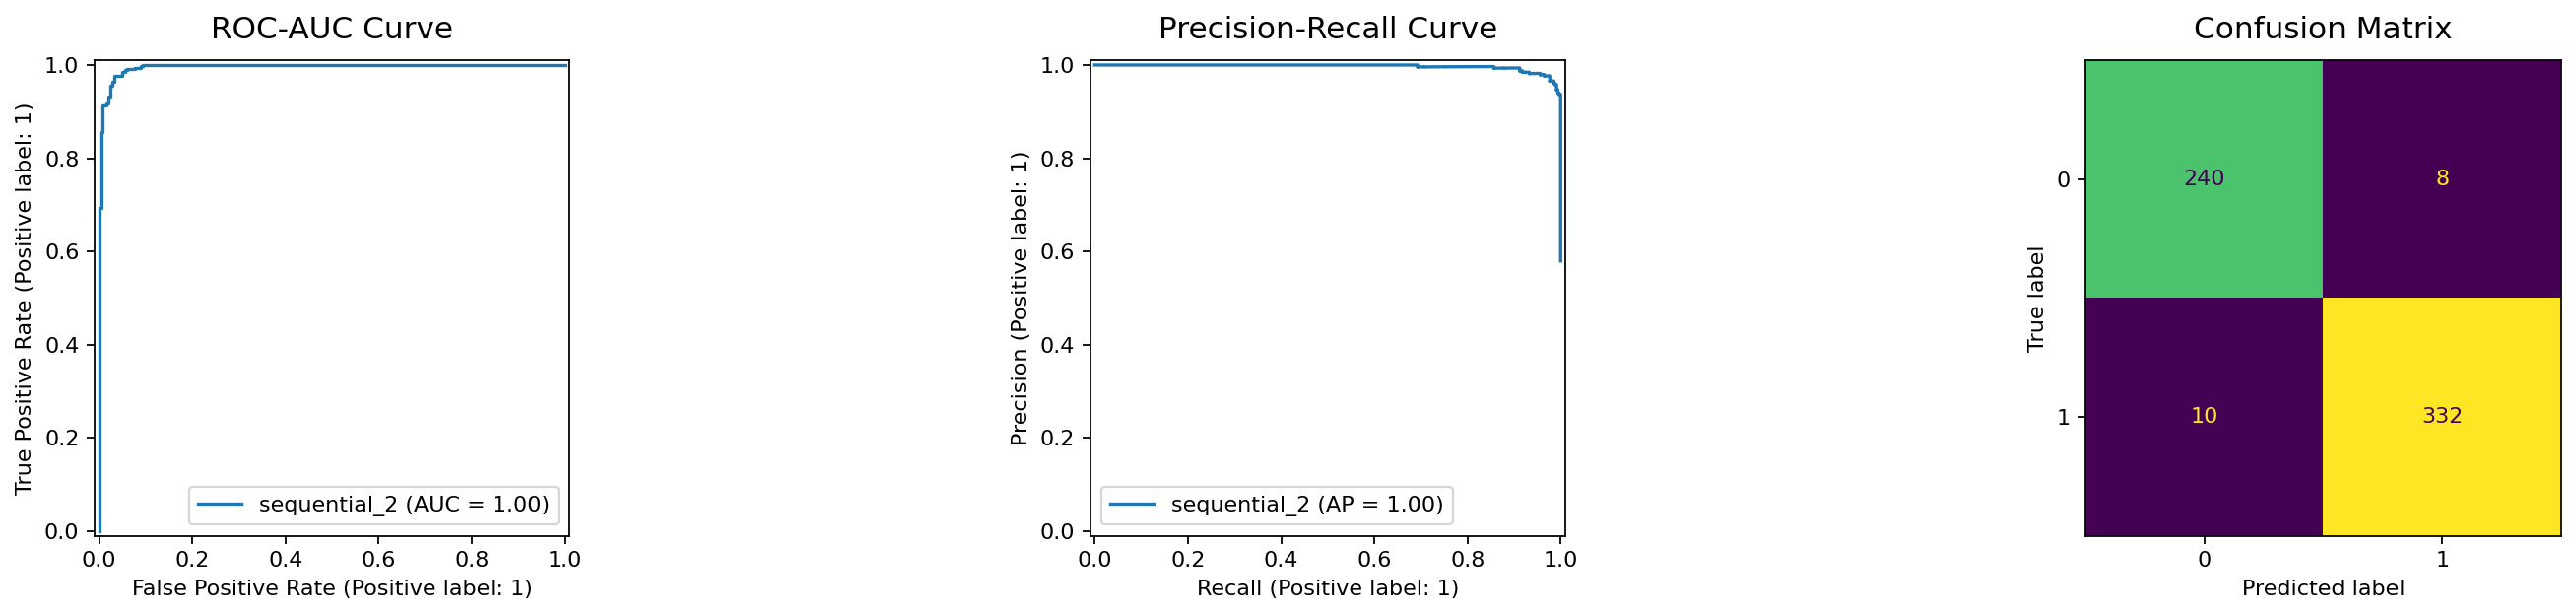

In [ ]:
import numpy as np
evaluate_model(model1)

***Create MobileNet Model***

In [ ]:
from tensorflow.keras.applications import MobileNet

MobileNet_model =MobileNet(weights='imagenet', include_top=False, input_shape=(128, 128, 3))



# Add your own dense layers on top of MobileNetV1
model2 = tf.keras.Sequential([
    MobileNet_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Assuming binary classification
])


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


***Train MobileNet Model***

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - binary_accuracy: 0.8235 - loss: 0.3785 - roc_auc: 0.8898 - val_binary_accuracy: 0.8763 - val_loss: 0.2835 - val_roc_auc: 0.9781 - learning_rate: 1.0000e-04
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - binary_accuracy: 0.9698 - loss: 0.0899 - roc_auc: 0.9945 - val_binary_accuracy: 0.9322 - val_loss: 0.1858 - val_roc_auc: 0.9901 - learning_rate: 1.0000e-04
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - binary_accuracy: 0.9865 - loss: 0.0442 - roc_auc: 0.9986 - val_binary_accuracy: 0.9508 - val_loss: 0.1319 - val_roc_auc: 0.9892 - learning_rate: 1.0000e-04
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 428s 3s/step - binary_accuracy: 0.9816 - loss: 0.0508 - roc_auc: 0.9984 - val_binary_accuracy: 0.9534 - val_loss: 0.1420 - val_roc_auc: 0.9923 - learning_rate: 1.0000e-04
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 394s 3s/step - binary_accuracy: 0.9908 - loss: 0.0350 - roc_auc: 0.9995 - val_binary_accuracy: 0.9542 - val_loss: 0.

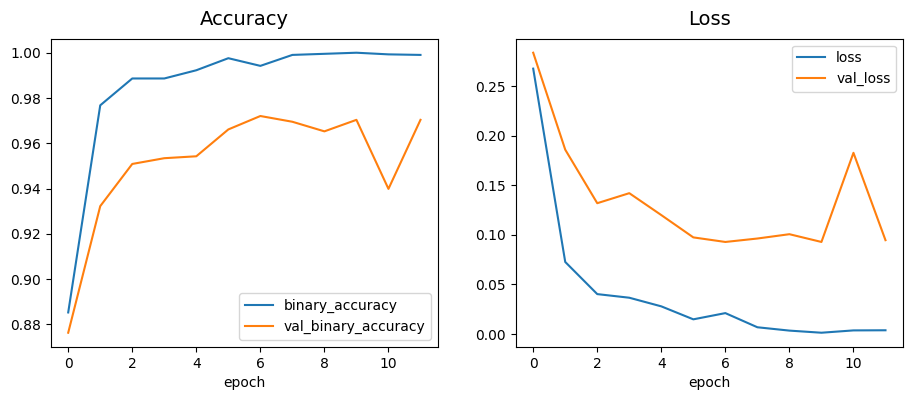

In [ ]:
# Compile and fit the model
MobileNet_history= compile_and_fit_model(model2)

In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_128 (Functional)      │ (None, 4, 4, 1024)          │       3,228,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,430,789 (39.79 MB)

 Trainable params: 3,469,633 (13.24 MB)

 Non-trainable params: 21,888 (85.50 KB)

 Optimizer params: 6,939,268 (26.47 MB)

***Evaluate MobileNet Model***

,Metric,Value
0,ROC-AUC,0.996
1,Accuracy,0.976
2,Loss,0.073


,precision,recall,f1-score,support
0,0.971774,0.971774,0.971774,248.000
1,0.979532,0.979532,0.979532,342.000
accuracy,0.976271,0.976271,0.976271,0.976
macro avg,0.975653,0.975653,0.975653,590.000
weighted avg,0.976271,0.976271,0.976271,590.000


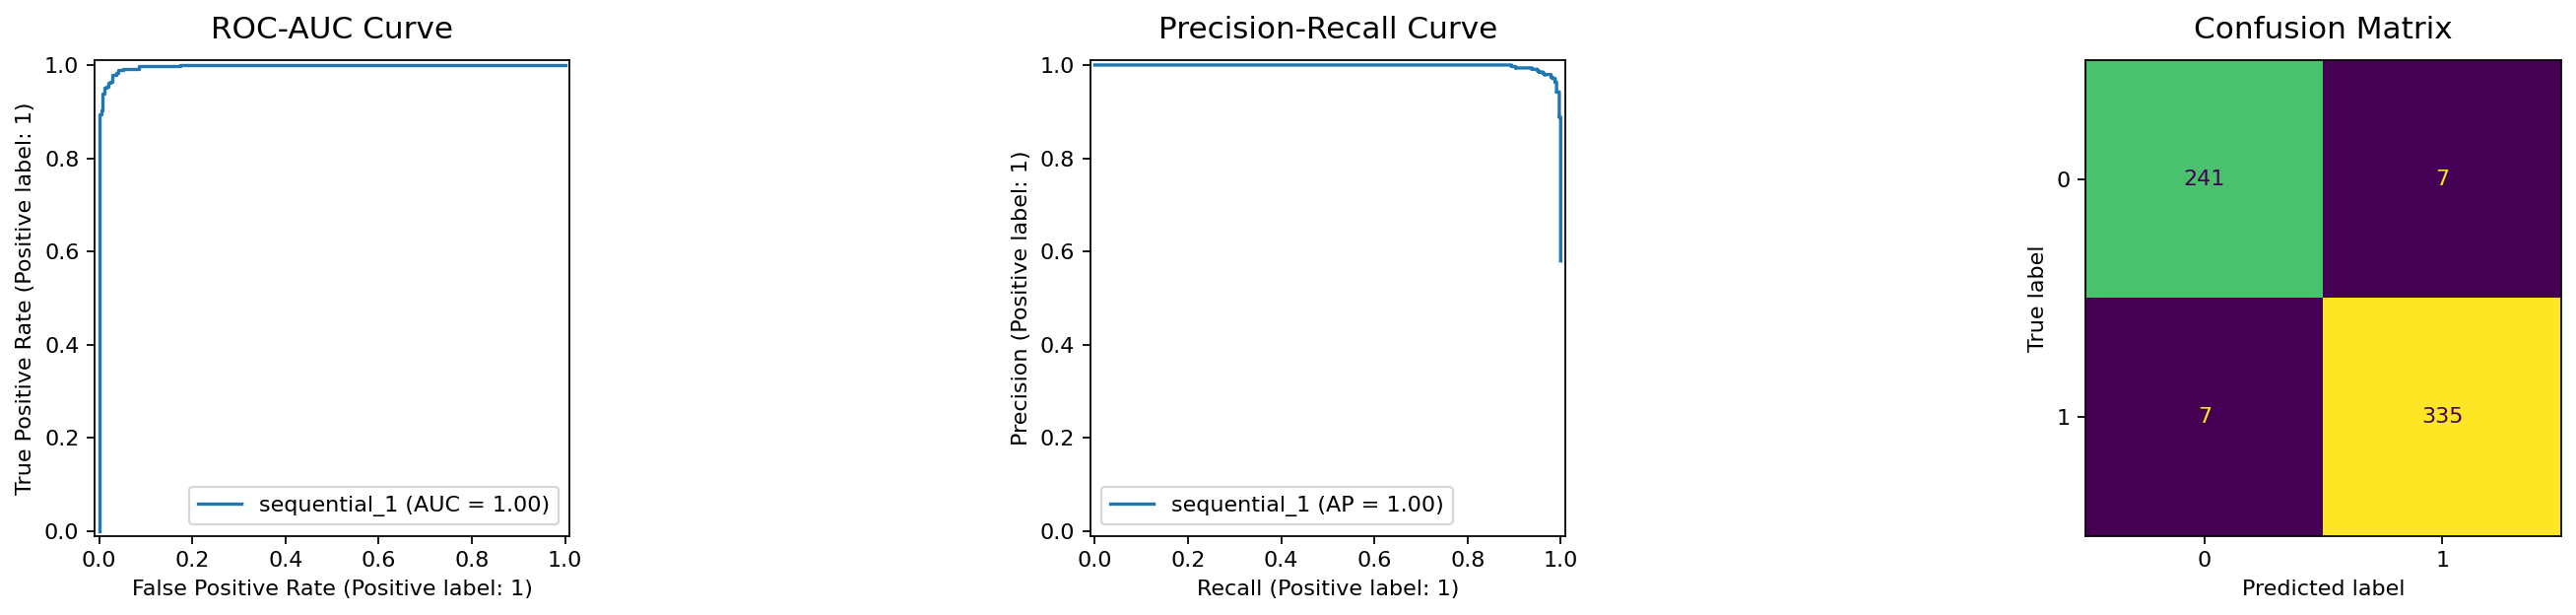

In [ ]:
import numpy as np
evaluate_model(model2)

***Copare Base Models Performance***

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Define your models and their names manually
fitted_models = [model1,model2]
model_names = ["Base 1: EfficientNetB0", "Base 2: MobileNetV1"]  # List of model names

# Create a DataFrame with evaluation metrics (Loss, ROC-AUC, Accuracy) for each model
test_metrics = pd.DataFrame(
    {name: model.evaluate(test_ds, verbose=0) for name, model in zip(model_names, fitted_models)},
    index=["Loss","ROC-AUC","Accuracy"]
)

# Apply styling to highlight the minimum and maximum values
test_metrics.style.highlight_min(color="pink", axis=1)\
                  .highlight_max(color="lawngreen", axis=1)


,Base 1: EfficientNetB0,Base 2: MobileNetV1
Loss,0.080017,0.065293
ROC-AUC,0.994559,0.996587
Accuracy,0.967797,0.977966


***Create Data for Meta Model***

In [ ]:
def get_predictions_and_labels(dataset: tf.data.Dataset) -> Tuple:
    # Get labels and predictions for each batch in dataset
    results = [(labels, [model.predict(images, verbose=0).reshape(-1,)
                         for model in fitted_models])
               for images, labels in dataset.take(-1)]
    labels = np.concatenate([x[0] for x in results])
    # Combine predictions, then transpose to shape (nsamples, nmodels)
    preds = np.concatenate([x[1] for x in results], axis=1).transpose()
    return preds, labels


#train_preds, train_labels = get_predictions_and_labels(train_ds)
valid_preds, valid_labels = get_predictions_and_labels(validation_ds)
test_preds, test_labels = get_predictions_and_labels(test_ds)

***Visual Features Extraction of Base Model***

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


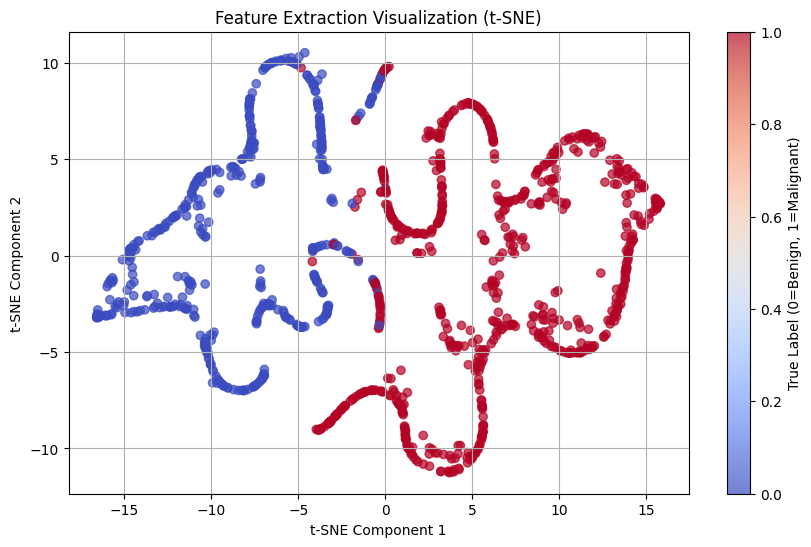

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
valid_preds_scaled = scaler.fit_transform(valid_preds)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(valid_preds_scaled)


from sklearn.manifold import TSNE

# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
reduced_features_tsne = tsne.fit_transform(valid_preds_scaled)

# Plot the t-SNE reduced features
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_features_tsne[:, 0], reduced_features_tsne[:, 1],
                      c=valid_labels, cmap='coolwarm', alpha=0.7)
plt.title('Feature Extraction Visualization (t-SNE)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, label='True Label (0=Benign, 1=Malignant)')
plt.grid(True)
plt.show()


***Create Stacking Evaluate Model***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_auc_score, log_loss
from sklearn import metrics

def evaluate_stacking_model(model,test_preds, test_labels,valid_preds, valid_labels) -> None:

    # Final evaluation on the test set
    #Predict on the test set
    stacked_preds = model.predict(test_preds)
    final_pred_probs =model.predict_proba(test_preds)[:, 1]

    #Calculate metrics for the test set
    auc = roc_auc_score(test_labels, final_pred_probs)
    accuracy = accuracy_score(test_labels, stacked_preds)
    loss = log_loss(test_labels, final_pred_probs)

    # Create a DataFrame for metrics
    metrics_df = pd.DataFrame({
        'Metric': ['ROC-AUC', 'Accuracy', 'Loss'],
        'Value': [auc, accuracy, loss]
    })

    # Style the metrics DataFrame
    styled_metrics = metrics_df.style.background_gradient(cmap="coolwarm") \
                                         .set_caption(f"Evaluation Metrics for Logistic Regression Stacking Model") \
                                         .format({'Value': "{:.3f}"})  # Format for the 'Value' column only

    # Display the styled metrics table
    display(styled_metrics)

    # Convert classification report to a DataFrame
    class_report = classification_report(test_labels, stacked_preds.round().astype("uint8"), output_dict=True)
    class_report_df = pd.DataFrame(class_report).T

    # Style the classification report with a color gradient, formatting numeric columns
    styled_report = class_report_df.style.background_gradient(cmap="coolwarm") \
                                         .set_caption(f"Classification Report for Logistic Regression Stacking Model")

    # Format only numeric columns in the classification report
    for col in class_report_df.columns[1:]:  # Skip the first column (class names)
        styled_report = styled_report.format({col: "{:.3f}"})  # Format numeric columns

    # Display the styled classification report
    display(styled_report)

    # Plot additional metrics (ROC Curve, Precision-Recall Curve, Confusion Matrix)
    fig, axes = plt.subplots(ncols=3, figsize=(20, 4), dpi=160)
    curves = [metrics.RocCurveDisplay, metrics.PrecisionRecallDisplay]
    for ax, curve in zip(axes[:2], curves):
        curve.from_predictions(test_labels, model.predict_proba(test_preds)[:, 1], ax=ax, name="Logistic Regression")
    metrics.ConfusionMatrixDisplay.from_predictions(
        test_labels, stacked_preds.round().astype("uint8"), ax=axes[2], colorbar=False,
    )
    titles = ["ROC-AUC Curve", "Precision-Recall Curve", "Confusion Matrix"]
    for ax, title in zip(axes.flat, titles):
        ax.set_title(title, size=14, pad=10)

    plt.tight_layout()
    plt.show()

    return loss,auc,accuracy


***Train Meta Model with k-fold method and Evaluated Meta Model***

,Metric,Value
0,ROC-AUC,0.999
1,Accuracy,0.985
2,Loss,0.047


,precision,recall,f1-score,support
0,0.983806,0.979839,0.981818,248.000
1,0.985423,0.988304,0.986861,342.000
accuracy,0.984746,0.984746,0.984746,0.985
macro avg,0.984614,0.984071,0.984340,590.000
weighted avg,0.984743,0.984746,0.984741,590.000


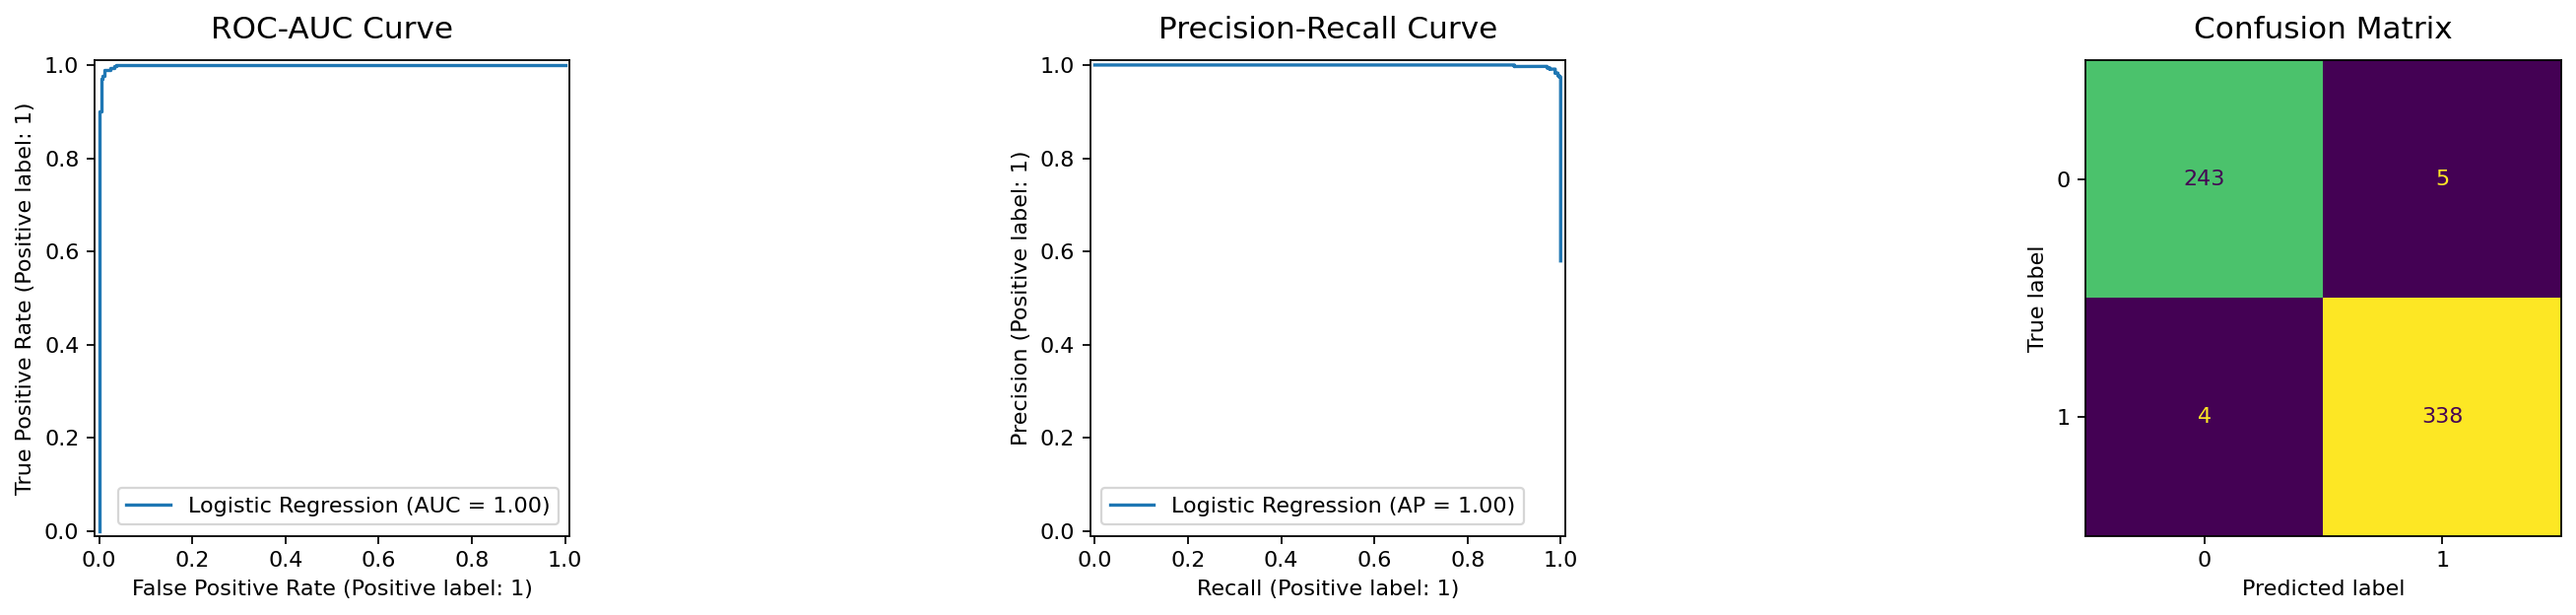

In [ ]:
from sklearn.linear_model import LogisticRegression

stacking_model=LogisticRegression()
stacking_model.fit(valid_preds,valid_labels)


loss,auc,accuracy=evaluate_stacking_model(stacking_model,test_preds, test_labels,valid_preds, valid_labels)

***Compare Base Models and Meta Model***

In [ ]:


test_metrics["Stacking Ensemble"]=[


    loss,
    auc,
    accuracy

]

# Apply styling to highlight the minimum and maximum values
styled_metrics=test_metrics.style.highlight_min(color="pink", axis=1)\
                  .highlight_max(color="lawngreen", axis=1)

styled_metrics

,Base 1: EfficientNetB0,Base 2: MobileNetV1,Stacking Ensemble
Loss,0.080017,0.065293,0.046821
ROC-AUC,0.994559,0.996587,0.999186
Accuracy,0.967797,0.977966,0.984746


***Visualization of Final Performance of Model***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


Predictions model 1 shape: (10, 1)
Predictions model 2 shape: (10, 1)
Predicted probabilities from stacking model:
 [[0.98220961 0.01779039]
 [0.00902777 0.99097223]
 [0.00905446 0.99094554]
 [0.98220967 0.01779033]
 [0.00902305 0.99097695]
 [0.98220292 0.01779708]
 [0.00908191 0.99091809]
 [0.00901117 0.99098883]
 [0.98220965 0.01779035]
 [0.98220926 0.01779074]]


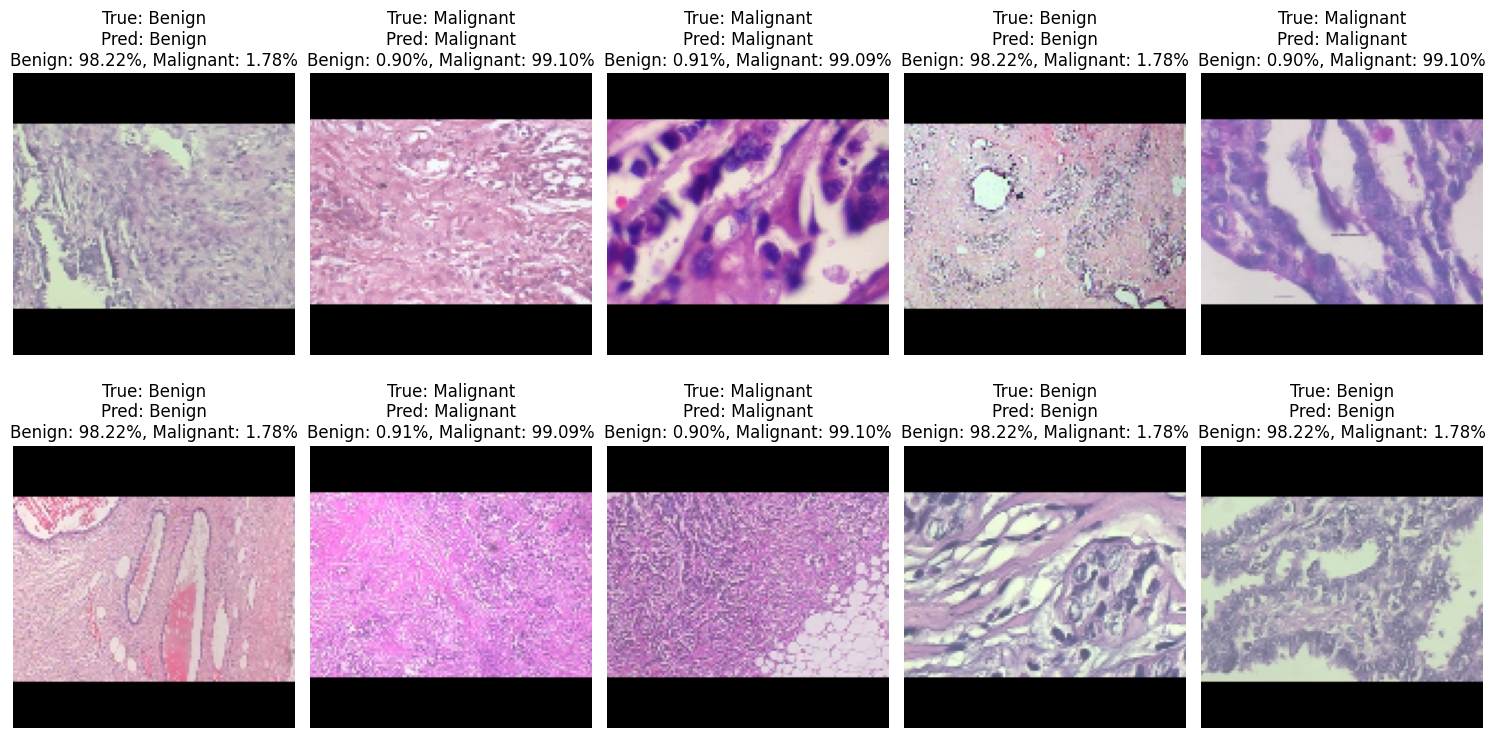

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have two base models: model1 and model2
# Assuming `stacking_model` is your Logistic Regression model

# Create a function to get the class names (assuming binary classification)
class_names = ['Benign', 'Malignant']

# Create an iterator for the dataset
train_ds_iter = iter(train_ds)

# Get 10 images (5 benign, 5 malignant) from the dataset
images, labels = [], []
benign_count, malignant_count = 0, 0

while benign_count < 5 or malignant_count < 5:
    # Get a batch of images and labels
    batch_images, batch_labels = next(train_ds_iter)

    for img, label in zip(batch_images, batch_labels):
        if benign_count < 5 and label == 0:  # Benign (assuming benign is labeled as 0)
            images.append(img)
            labels.append(label)
            benign_count += 1
        elif malignant_count < 5 and label == 1:  # Malignant (assuming malignant is labeled as 1)
            images.append(img)
            labels.append(label)
            malignant_count += 1
        if benign_count >= 5 and malignant_count >= 5:
            break

# Convert images to numpy array
images_np = np.array([img.numpy() for img in images])

# Get predictions from base models (use the original images)
predictions_model1 = model1.predict(images_np)  # Probability of benign class (or probabilities for both classes)
predictions_model2 = model2.predict(images_np)  # Probability of benign class (or probabilities for both classes)

# Check the shape of predictions
print("Predictions model 1 shape:", predictions_model1.shape)
print("Predictions model 2 shape:", predictions_model2.shape)

# Flatten the predictions to ensure they are 1D
predictions_model1_probs = predictions_model1.flatten()  # Probability of class 1 (malignant)
predictions_model2_probs = predictions_model2.flatten()  # Probability of class 1 (malignant)

# Stack the predictions to use as input for the stacking model
stacked_predictions = np.column_stack((predictions_model1_probs, predictions_model2_probs))  # Shape should be (10, 2)

# Predict the class probabilities using the stacking model
predictions = stacking_model.predict_proba(stacked_predictions)  # Use predict_proba for probabilities

# Inspect predicted probabilities
print("Predicted probabilities from stacking model:\n", predictions)

# Plot the images with the predicted class and confidence
plt.figure(figsize=(15, 8))

# Example of using a custom threshold
custom_threshold = 0.5  # Adjust as needed

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)

    # Access the predicted probabilities for both classes
    benign_prob = predictions[i][0]  # Probability of benign class (index 0)
    malignant_prob = predictions[i][1]  # Probability of malignant class (index 1)

    # Determine the predicted class based on the custom threshold for malignant
    predicted_class = int(malignant_prob > custom_threshold)  # 1 for malignant, 0 for benign
    true_label = int(labels[i])

    # Convert the malignant probability to percentage
    predicted_percentage = malignant_prob * 100  # Convert malignant probability to percentage

    # Set the title with true label, predicted class, and confidence percentage
    ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_class]}\n"
                 f"Benign: {benign_prob * 100:.2f}%, Malignant: {malignant_prob * 100:.2f}%")

    # Display the image
    plt.imshow(images_np[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf

# Assuming 'model' is your trained Keras model
# Change 'your_username' to your actual username on your computer
model1.save(r'C:\Users\rakib\OneDrive\Desktop\Thesis\Models\EfficientNetB0.h5')



In [ ]:
model2.save(r'C:\Users\rakib\OneDrive\Desktop\Thesis\Models\MobileNet.h5')

***Thanks নাতি***